## MMS - Tugas Kecerdasan Artifisial <br>
 - <a href="https://github.com/mackorone/mms?tab=readme-ov-file">Github MMS - Micromouse simulator</a>
 - <a href="https://en.wikipedia.org/wiki/Micromouse">Wikipedia : Micromouse</a> 
 - <a href="https://github.com/micromouseonline/mazefiles">mazefiles</a> 
***

### Jurnal

- <a href="https://www.mdpi.com/2072-666X/16/11/1273#app1-micromachines-16-01273">Secure Angle-Based Geometric Elimination (SAGE) for Microrobot Path Planning</a>

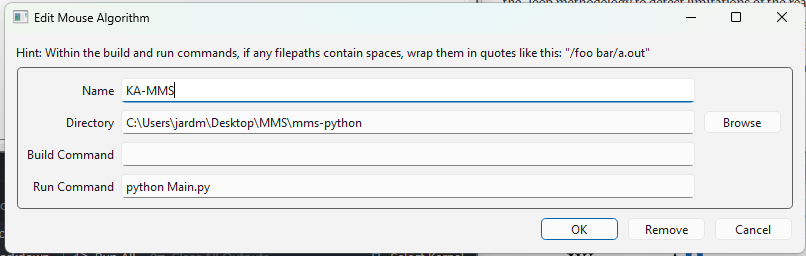

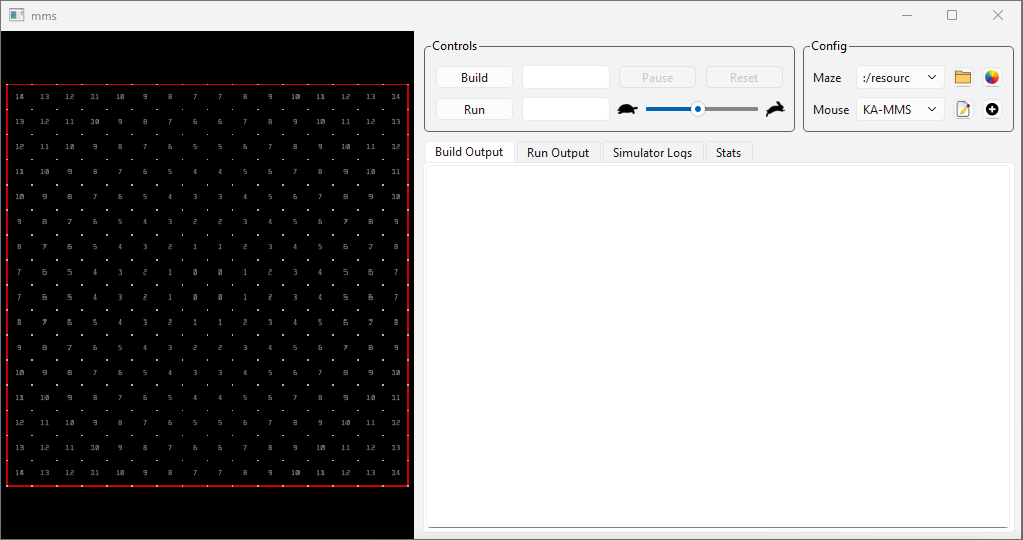

### Tanpa alogritma Dijkstra

In [ ]:
import API
import sys
import time
from pathlib import Path

# =========================================================
# Config
# =========================================================
MAZE_FILE = r"..\maze\mazefiles\classic\AAMC15Maze.txt"

# 0=N, 1=E, 2=S, 3=W
DIRS = [(0, 1), (1, 0), (0, -1), (-1, 0)]


# =========================================================
# Logging
# =========================================================
def log(msg):
    sys.stderr.write(str(msg) + "\n")
    sys.stderr.flush()


# =========================================================
# Parse maze ASCII MMS
# =========================================================
def parse_maze_ascii(path):
    lines = Path(path).read_text(encoding="utf-8").splitlines()
    lines = [line.rstrip("\n") for line in lines if line.strip()]

    height = (len(lines) - 1) // 2
    width = (len(lines[0]) - 1) // 4

    walls = {}
    start = None
    goals = []

    for rr in range(height):
        content_line = lines[1 + 2 * rr]
        north_line = lines[2 * rr]
        south_line = lines[2 * rr + 2]

        y = height - 1 - rr

        for x in range(width):
            cx = 2 + 4 * x
            west_idx = 4 * x
            east_idx = 4 * x + 4

            cell_char = content_line[cx]
            north_wall = "-" in north_line[1 + 4 * x : 4 + 4 * x]
            south_wall = "-" in south_line[1 + 4 * x : 4 + 4 * x]
            west_wall = content_line[west_idx] == "|"
            east_wall = content_line[east_idx] == "|"

            walls[(x, y)] = [north_wall, east_wall, south_wall, west_wall]

            if cell_char == "S":
                start = (x, y)
            elif cell_char == "G":
                goals.append((x, y))

    return width, height, walls, start, goals


# =========================================================
# Helper graph
# =========================================================
def in_bounds(x, y, w, h):
    return 0 <= x < w and 0 <= y < h


def neighbor(cell, d):
    x, y = cell
    dx, dy = DIRS[d]
    return (x + dx, y + dy)


def can_move(cell, d, walls, w, h):
    if walls[cell][d]:
        return False
    nx, ny = neighbor(cell, d)
    return in_bounds(nx, ny, w, h)


def get_neighbors(cell, walls, w, h):
    result = []
    for d in range(4):
        if can_move(cell, d, walls, w, h):
            result.append((neighbor(cell, d), d))
    return result


# =========================================================
# DFS route builder
# =========================================================
def build_dfs_route(start, walls, w, h):
    visited = set()
    route = []

    def dfs(cell):
        visited.add(cell)
        route.append(cell)

        for nxt, _ in get_neighbors(cell, walls, w, h):
            if nxt not in visited:
                dfs(nxt)
                route.append(cell)  # backtrack ke parent

    dfs(start)
    return route


def path_to_dirs(path):
    dirs = []
    for i in range(len(path) - 1):
        x1, y1 = path[i]
        x2, y2 = path[i + 1]

        if (x2, y2) == (x1, y1 + 1):
            dirs.append(0)
        elif (x2, y2) == (x1 + 1, y1):
            dirs.append(1)
        elif (x2, y2) == (x1, y1 - 1):
            dirs.append(2)
        elif (x2, y2) == (x1 - 1, y1):
            dirs.append(3)
        else:
            raise ValueError(f"Path tidak valid: {(x1, y1)} -> {(x2, y2)}")
    return dirs


# =========================================================
# Visualisasi
# =========================================================
def draw_targets(goals):
    for x, y in goals:
        API.setText(x, y, "T")
        API.setColor(x, y, "y")


def mark_done(goal):
    x, y = goal
    API.setText(x, y, "OK")
    API.setColor(x, y, "g")


def draw_route(path):
    for x, y in path:
        API.setColor(x, y, "g")


# =========================================================
# Robot control
# =========================================================
class Robot:
    def __init__(self, start):
        self.x, self.y = start
        self.dir = 0  # default utara

    def pos(self):
        return (self.x, self.y)

    def turn_left(self):
        API.turnLeft()
        self.dir = (self.dir - 1) % 4

    def turn_right(self):
        API.turnRight()
        self.dir = (self.dir + 1) % 4

    def face(self, target_dir):
        diff = (target_dir - self.dir) % 4
        if diff == 1:
            self.turn_right()
        elif diff == 2:
            self.turn_right()
            self.turn_right()
        elif diff == 3:
            self.turn_left()

    def move_forward(self):
        if API.wallFront():
            log(f"Dinding terdeteksi di depan pada posisi {self.pos()} arah {self.dir}")
            return False

        API.moveForward()
        self.x, self.y = neighbor((self.x, self.y), self.dir)
        return True


# =========================================================
# Main
# =========================================================
def main():
    log("Running DFS Smart Farming...")

    w, h, walls, start, goals = parse_maze_ascii(MAZE_FILE)
    if start is None:
        log("Start 'S' tidak ditemukan.")
        return
    if not goals:
        log("Target 'G' tidak ditemukan.")
        return

    robot = Robot(start)
    remaining = set(goals)
    visit_count = {(x, y): 0 for x in range(w) for y in range(h)}
    visit_count[start] = 1

    API.setColor(start[0], start[1], "G")
    API.setText(start[0], start[1], "S")
    draw_targets(goals)

    dfs_route = build_dfs_route(start, walls, w, h)
    draw_route(dfs_route)

    dirs = path_to_dirs(dfs_route)

    total_steps = 0
    start_time = time.perf_counter()

    for d in dirs:
        robot.face(d)

        if not robot.move_forward():
            log("Robot gagal bergerak. Program dihentikan.")
            break

        total_steps += 1
        visit_count[robot.pos()] += 1

        if robot.pos() in remaining:
            remaining.remove(robot.pos())
            mark_done(robot.pos())
            log(f"Target tercapai: {robot.pos()}")

        if not remaining:
            break

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    revisit_total = sum(v - 1 for v in visit_count.values() if v > 1)
    target_done = len(goals) - len(remaining)

    log("===== HASIL =====")
    log(f"Total langkah           = {total_steps}")
    log(f"Jumlah target tercapai  = {target_done}")
    log(f"Jumlah revisit          = {revisit_total}")
    log(f"Waktu penyelesaian      = {elapsed_time:.4f} detik")


if __name__ == "__main__":
    main()

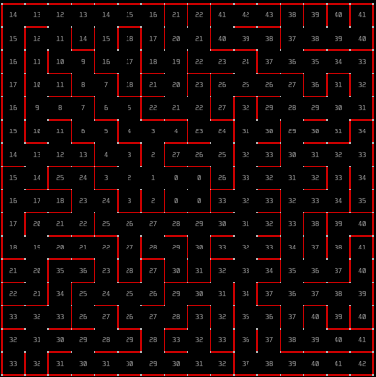
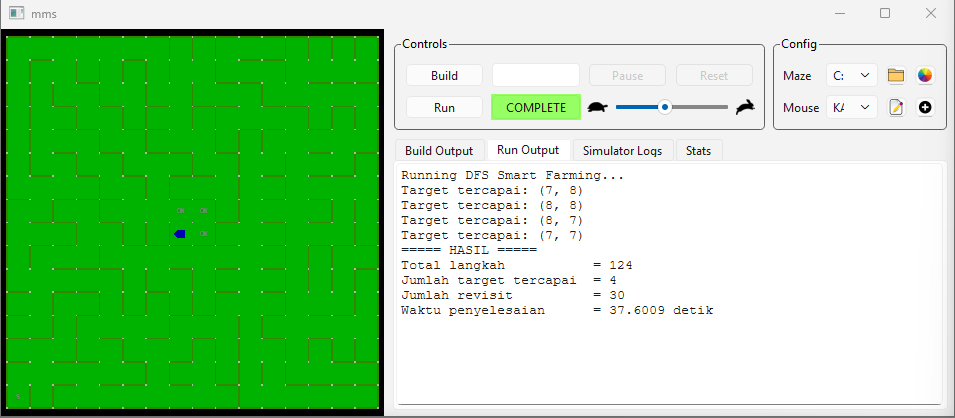

### Alogritma Dijkstra

In [ ]:
import API
import sys
import math
import heapq
import time
from pathlib import Path

# =========================================================
# Config
# =========================================================
MAZE_FILE = r"..\maze\mazefiles\classic\AAMC15Maze.txt"
ALPHA = 2.0   # makin besar = makin menghindari lintasan berulang

# 0=N, 1=E, 2=S, 3=W
DIRS = [(0, 1), (1, 0), (0, -1), (-1, 0)]


# =========================================================
# Logging
# =========================================================
def log(msg):
    sys.stderr.write(str(msg) + "\n")
    sys.stderr.flush()


# =========================================================
# Parse maze ASCII MMS
# =========================================================
def parse_maze_ascii(path):
    lines = Path(path).read_text(encoding="utf-8").splitlines()
    lines = [line.rstrip("\n") for line in lines if line.strip()]

    height = (len(lines) - 1) // 2
    width = (len(lines[0]) - 1) // 4

    walls = {}
    start = None
    goals = []

    for rr in range(height):
        content_line = lines[1 + 2 * rr]
        north_line = lines[2 * rr]
        south_line = lines[2 * rr + 2]

        y = height - 1 - rr

        for x in range(width):
            cx = 2 + 4 * x
            west_idx = 4 * x
            east_idx = 4 * x + 4

            cell_char = content_line[cx]
            north_wall = "-" in north_line[1 + 4 * x:4 + 4 * x]
            south_wall = "-" in south_line[1 + 4 * x:4 + 4 * x]
            west_wall = content_line[west_idx] == "|"
            east_wall = content_line[east_idx] == "|"

            walls[(x, y)] = [north_wall, east_wall, south_wall, west_wall]

            if cell_char == "S":
                start = (x, y)
            elif cell_char == "G":
                goals.append((x, y))

    return width, height, walls, start, goals


# =========================================================
# Graph helpers
# =========================================================
def in_bounds(x, y, w, h):
    return 0 <= x < w and 0 <= y < h


def neighbor(cell, direction):
    x, y = cell
    dx, dy = DIRS[direction]
    return (x + dx, y + dy)


def can_move(cell, direction, walls, w, h):
    if walls[cell][direction]:
        return False
    nx, ny = neighbor(cell, direction)
    return in_bounds(nx, ny, w, h)


# =========================================================
# Weighted Dijkstra
# =========================================================
def cell_cost(cell, visit_count):
    n = visit_count.get(cell, 0)
    return 1.0 + ALPHA * math.log1p(n)


def weighted_dijkstra(start, goal, walls, w, h, visit_count):
    pq = [(0.0, start)]
    dist = {start: 0.0}
    prev = {}

    while pq:
        cur_cost, cur = heapq.heappop(pq)

        if cur == goal:
            break

        if cur_cost > dist[cur]:
            continue

        for d in range(4):
            if can_move(cur, d, walls, w, h):
                nxt = neighbor(cur, d)
                new_cost = cur_cost + cell_cost(nxt, visit_count)

                if nxt not in dist or new_cost < dist[nxt]:
                    dist[nxt] = new_cost
                    prev[nxt] = cur
                    heapq.heappush(pq, (new_cost, nxt))

    if goal not in dist:
        return None, None

    path = []
    cur = goal
    while cur != start:
        path.append(cur)
        cur = prev[cur]
    path.append(start)
    path.reverse()

    return path, dist


def choose_next_target(current, targets, walls, w, h, visit_count):
    best_target = None
    best_path = None
    best_cost = float("inf")
    best_distmap = None

    for t in targets:
        path, distmap = weighted_dijkstra(current, t, walls, w, h, visit_count)
        if path is None:
            continue

        total = 0.0
        for cell in path[1:]:
            total += cell_cost(cell, visit_count)

        if total < best_cost:
            best_cost = total
            best_target = t
            best_path = path
            best_distmap = distmap

    return best_target, best_path, best_distmap


# =========================================================
# Visualisasi di MMS
# =========================================================
def draw_targets(goals):
    for x, y in goals:
        API.setText(x, y, "T")
        API.setColor(x, y, "R")


def mark_done(goal):
    x, y = goal
    API.setText(x, y, "OK")
    API.setColor(x, y, "g")


def draw_path(path):
    for x, y in path:
        API.setColor(x, y, "y")


def clear_path(path, remaining_goals, start):
    remaining_goals = set(remaining_goals)
    for x, y in path:
        if (x, y) in remaining_goals:
            API.setColor(x, y, "y")
            API.setText(x, y, "T")
        elif (x, y) == start:
            API.setColor(x, y, "G")
            API.setText(x, y, "S")
        else:
            API.clearColor(x, y)


def show_distances(distmap, w, h, goals, start):
    for y in range(h):
        for x in range(w):
            if (x, y) == start:
                API.setText(x, y, "S")
            elif (x, y) in goals:
                API.setText(x, y, "T")
            elif (x, y) in distmap:
                API.setText(x, y, str(int(distmap[(x, y)])))
            else:
                API.setText(x, y, "inf")


# =========================================================
# Gerak robot di simulator
# =========================================================
class Robot:
    def __init__(self, start):
        self.x, self.y = start
        self.dir = 0  # default utara

    def turn_left(self):
        API.turnLeft()
        self.dir = (self.dir - 1) % 4

    def turn_right(self):
        API.turnRight()
        self.dir = (self.dir + 1) % 4

    def face(self, target_dir):
        diff = (target_dir - self.dir) % 4
        if diff == 1:
            self.turn_right()
        elif diff == 2:
            self.turn_right()
            self.turn_right()
        elif diff == 3:
            self.turn_left()

    def move_forward(self):
        if API.wallFront():
            log(f"Dinding terdeteksi di depan pada posisi {self.pos()} arah {self.dir}")
            return False

        API.moveForward()
        self.x, self.y = neighbor((self.x, self.y), self.dir)
        return True

    def pos(self):
        return (self.x, self.y)


def path_to_dirs(path):
    dirs = []
    for i in range(len(path) - 1):
        x1, y1 = path[i]
        x2, y2 = path[i + 1]

        if (x2, y2) == (x1, y1 + 1):
            dirs.append(0)
        elif (x2, y2) == (x1 + 1, y1):
            dirs.append(1)
        elif (x2, y2) == (x1, y1 - 1):
            dirs.append(2)
        elif (x2, y2) == (x1 - 1, y1):
            dirs.append(3)
        else:
            raise ValueError(f"Path tidak valid: {(x1, y1)} -> {(x2, y2)}")
    return dirs


# =========================================================
# Statistik
# =========================================================
def count_revisits(visit_count):
    return sum(v - 1 for v in visit_count.values() if v > 1)


# =========================================================
# Main
# =========================================================
def main():
    log("Running Weighted Dijkstra Smart Farming...")

    w, h, walls, start, goals = parse_maze_ascii(MAZE_FILE)
    if start is None:
        log("Start 'S' tidak ditemukan pada file maze.")
        return
    if not goals:
        log("Target 'G' tidak ditemukan pada file maze.")
        return

    visit_count = {(x, y): 0 for x in range(w) for y in range(h)}
    visit_count[start] = 1

    robot = Robot(start)
    remaining = set(goals)

    API.setColor(start[0], start[1], "G")
    API.setText(start[0], start[1], "S")
    draw_targets(goals)

    step_total = 0
    start_time = time.perf_counter()
    while remaining:
        current = robot.pos()
        target, path, distmap = choose_next_target(current, remaining, walls, w, h, visit_count)

        if path is None:
            log("Tidak ada path ke target berikutnya.")
            break

        show_distances(distmap, w, h, remaining, start)
        draw_targets(remaining)
        API.setColor(start[0], start[1], "G")
        API.setText(start[0], start[1], "S")
        draw_path(path)

        log(f"Dari {current} menuju {target}, panjang path = {len(path)-1}")

        blocked = False
        for d in path_to_dirs(path):
            log(f"Posisi {robot.pos()} -> arah {d}")
            robot.face(d)

            if not robot.move_forward():
                log("Path tidak cocok dengan kondisi simulator. Replanning...")
                blocked = True
                break

            step_total += 1
            visit_count[robot.pos()] += 1

        if blocked:
            clear_path(path, remaining, start)
            continue

        reached = robot.pos()
        if reached in remaining:
            remaining.remove(reached)
            mark_done(reached)
            log(f"Target tercapai: {reached}")

        clear_path(path, remaining, start)

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    revisit_total = count_revisits(visit_count)

    log(f"Waktu penyelesaian = {elapsed_time:.4f} detik")
    log(f"Selesai. Total langkah = {step_total}")
    log(f"Jumlah target tercapai = {len(goals) - len(remaining)}")
    log(f"Jumlah revisit = {revisit_total}")


if __name__ == "__main__":
    main()

#### Uji COba
<p>MAZE_FILE = r"..\maze\mazefiles\classic\AAMC22Maze.txt"</p>

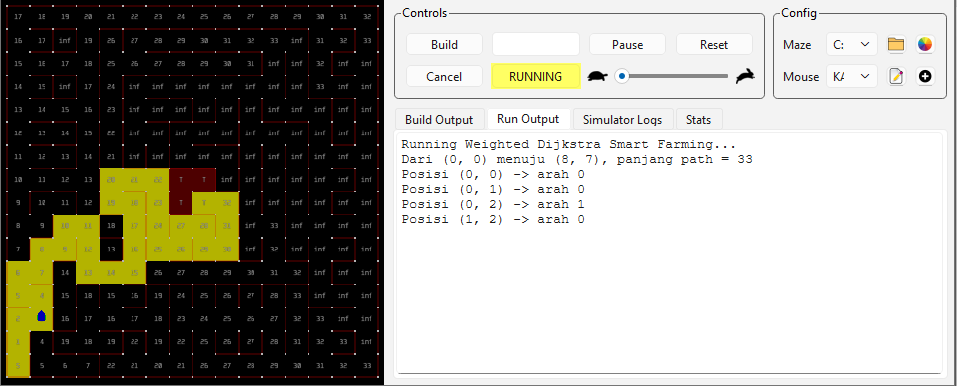 

### Algoritma Robot MMS

In [ ]:
import API
import sys
import time
import heapq

# =========================================================
# Konfigurasi
# =========================================================
MAZE_SIZE = 16

# 0=N, 1=E, 2=S, 3=W
DIRS = [(0, 1), (1, 0), (0, -1), (-1, 0)]

# Goal micromouse standar: 4 sel tengah
GOALS = {(7, 7), (7, 8), (8, 7), (8, 8)}


# =========================================================
# Logging
# =========================================================
def log(msg):
    sys.stderr.write(str(msg) + "\n")
    sys.stderr.flush()


# =========================================================
# Struktur peta
# walls[(x,y)] = [N, E, S, W]
# None  = belum diketahui
# True  = ada dinding
# False = tidak ada dinding
# =========================================================
walls = {}
visited = set()
parent = {}

for x in range(MAZE_SIZE):
    for y in range(MAZE_SIZE):
        walls[(x, y)] = [None, None, None, None]

# batas luar maze
for x in range(MAZE_SIZE):
    walls[(x, 0)][2] = True
    walls[(x, MAZE_SIZE - 1)][0] = True
for y in range(MAZE_SIZE):
    walls[(0, y)][3] = True
    walls[(MAZE_SIZE - 1, y)][1] = True


# =========================================================
# Helper grid
# =========================================================
def in_bounds(cell):
    x, y = cell
    return 0 <= x < MAZE_SIZE and 0 <= y < MAZE_SIZE


def neighbor(cell, d):
    x, y = cell
    dx, dy = DIRS[d]
    return (x + dx, y + dy)


def set_wall(cell, d, value):
    walls[cell][d] = value
    nb = neighbor(cell, d)
    if in_bounds(nb):
        walls[nb][(d + 2) % 4] = value


def is_goal(cell):
    return cell in GOALS


# =========================================================
# Robot
# =========================================================
class Robot:
    def __init__(self):
        self.x = 0
        self.y = 0
        self.dir = 0  # menghadap utara

    def pos(self):
        return (self.x, self.y)

    def turn_left(self):
        API.turnLeft()
        self.dir = (self.dir - 1) % 4

    def turn_right(self):
        API.turnRight()
        self.dir = (self.dir + 1) % 4

    def face(self, target_dir):
        diff = (target_dir - self.dir) % 4
        if diff == 1:
            self.turn_right()
        elif diff == 2:
            self.turn_right()
            self.turn_right()
        elif diff == 3:
            self.turn_left()

    def move_forward(self):
        if API.wallFront():
            log(f"Tertahan dinding di depan pada {self.pos()} arah {self.dir}")
            return False
        API.moveForward()
        self.x, self.y = neighbor(self.pos(), self.dir)
        return True


robot = Robot()


# =========================================================
# Sensor update
# =========================================================
def update_current_walls():
    cell = robot.pos()

    # depan, kiri, kanan relatif terhadap arah robot
    front = API.wallFront()
    left = API.wallLeft()
    right = API.wallRight()

    set_wall(cell, robot.dir, front)
    set_wall(cell, (robot.dir - 1) % 4, left)
    set_wall(cell, (robot.dir + 1) % 4, right)

    # arah belakang pasti terbuka jika robot bisa sampai ke sini,
    # kecuali cell start yang belum tentu
    back_dir = (robot.dir + 2) % 4
    if walls[cell][back_dir] is None:
        nb = neighbor(cell, back_dir)
        if in_bounds(nb) and nb in visited:
            set_wall(cell, back_dir, False)


def discover_neighbors(cell):
    result = []
    for d in range(4):
        nb = neighbor(cell, d)
        if in_bounds(nb) and walls[cell][d] is False:
            result.append((nb, d))
    return result


# =========================================================
# Visualisasi
# =========================================================
def mark_start():
    API.setColor(0, 0, "G")
    API.setText(0, 0, "S")


def mark_goals():
    for gx, gy in GOALS:
        API.setColor(gx, gy, "y")
        API.setText(gx, gy, "G")


def mark_explored(cell):
    x, y = cell
    API.setColor(x, y, "c")


def mark_path(path, color="g", text=""):
    for x, y in path:
        API.setColor(x, y, color)
        if text:
            API.setText(x, y, text)


# =========================================================
# Movement helpers
# =========================================================
def move_one_step_to(next_cell):
    cx, cy = robot.pos()
    nx, ny = next_cell

    if (nx, ny) == (cx, cy + 1):
        d = 0
    elif (nx, ny) == (cx + 1, cy):
        d = 1
    elif (nx, ny) == (cx, cy - 1):
        d = 2
    elif (nx, ny) == (cx - 1, cy):
        d = 3
    else:
        raise ValueError(f"Langkah tidak valid: {robot.pos()} -> {next_cell}")

    robot.face(d)
    return robot.move_forward()


def move_along_path(path):
    # path berisi [start, ..., goal]
    for nxt in path[1:]:
        if not move_one_step_to(nxt):
            return False
        update_current_walls()
    return True


# =========================================================
# Dijkstra
# =========================================================
def get_known_open_neighbors(cell):
    res = []
    for d in range(4):
        if walls[cell][d] is False:
            nb = neighbor(cell, d)
            if in_bounds(nb) and nb in visited:
                res.append(nb)
    return res


def dijkstra(start, goal):
    pq = [(0, start)]
    dist = {start: 0}
    prev = {}

    while pq:
        cur_dist, cur = heapq.heappop(pq)

        if cur == goal:
            break

        if cur_dist > dist[cur]:
            continue

        for nb in get_known_open_neighbors(cur):
            nd = cur_dist + 1
            if nb not in dist or nd < dist[nb]:
                dist[nb] = nd
                prev[nb] = cur
                heapq.heappush(pq, (nd, nb))

    if goal not in dist:
        return None

    path = []
    cur = goal
    while cur != start:
        path.append(cur)
        cur = prev[cur]
    path.append(start)
    path.reverse()
    return path


# =========================================================
# Eksplorasi DFS sampai goal ditemukan
# =========================================================
def explore_until_goal():
    current = robot.pos()
    visited.add(current)
    mark_explored(current)
    update_current_walls()

    while True:
        current = robot.pos()

        if is_goal(current):
            log(f"Goal ditemukan di {current}")
            return current

        # cari tetangga yang belum dikunjungi
        next_unvisited = None
        for nb, _ in discover_neighbors(current):
            if nb not in visited:
                next_unvisited = nb
                break

        if next_unvisited is not None:
            parent[next_unvisited] = current
            if move_one_step_to(next_unvisited):
                visited.add(next_unvisited)
                mark_explored(next_unvisited)
                update_current_walls()

                if is_goal(robot.pos()):
                    log(f"Goal ditemukan di {robot.pos()}")
                    return robot.pos()
            else:
                # bila ternyata tertutup, update peta lagi
                update_current_walls()
        else:
            # backtrack DFS
            if current == (0, 0):
                log("Semua area eksplorasi habis, goal tidak ditemukan.")
                return None

            prev_cell = parent[current]
            if not move_one_step_to(prev_cell):
                log("Gagal backtrack.")
                return None
            update_current_walls()


# =========================================================
# Main
# =========================================================
def main():
    log("Eksplorasi tanpa mengetahui maze dimulai...")
    mark_start()
    mark_goals()

    start_time = time.perf_counter()

    goal_found = explore_until_goal()
    if goal_found is None:
        log("Goal tidak ditemukan.")
        return

    time_to_goal = time.perf_counter() - start_time
    log(f"Waktu mencari goal = {time_to_goal:.4f} detik")

    # -----------------------------------------------------
    # Dijkstra: goal -> start
    # -----------------------------------------------------
    path_back = dijkstra(goal_found, (0, 0))
    if path_back is None:
        log("Path Dijkstra dari goal ke start tidak ditemukan.")
        return

    mark_path(path_back, color="m")
    log(f"Rute tercepat kembali ke start: {len(path_back)-1} langkah")
    if not move_along_path(path_back):
        log("Gagal kembali ke start.")
        return

    back_time = time.perf_counter() - start_time
    log(f"Sampai start kembali pada {back_time:.4f} detik")

    # -----------------------------------------------------
    # Tunggu 10 detik
    # -----------------------------------------------------
    log("Menunggu 5 detik di start...")
    time.sleep(5)

    # -----------------------------------------------------
    # Dijkstra: start -> goal
    # -----------------------------------------------------
    path_to_goal = dijkstra((0, 0), goal_found)
    if path_to_goal is None:
        log("Path Dijkstra dari start ke goal tidak ditemukan.")
        return

    mark_path(path_to_goal, color="g")
    log(f"Rute tercepat ke goal: {len(path_to_goal)-1} langkah")
    if not move_along_path(path_to_goal):
        log("Gagal kembali ke goal.")
        return

    total_time = time.perf_counter() - start_time
    log("===== HASIL =====")
    log(f"Goal ditemukan di        = {goal_found}")
    log(f"Waktu cari goal          = {time_to_goal:.4f} detik")
    log(f"Waktu sampai start lagi  = {back_time:.4f} detik")
    log(f"Waktu total selesai      = {total_time:.4f} detik")
    log(f"Jumlah sel dieksplorasi  = {len(visited)}")
    log(f"Panjang path goal->start = {len(path_back)-1}")
    log(f"Panjang path start->goal = {len(path_to_goal)-1}")


if __name__ == "__main__":
    main()

alljapan-006-1985-fin.txt <br>
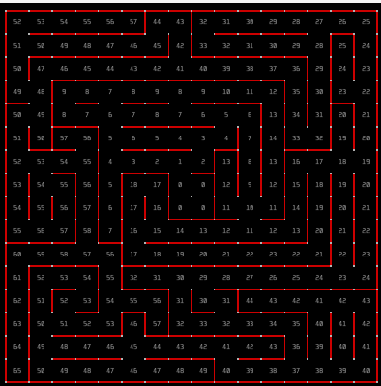 
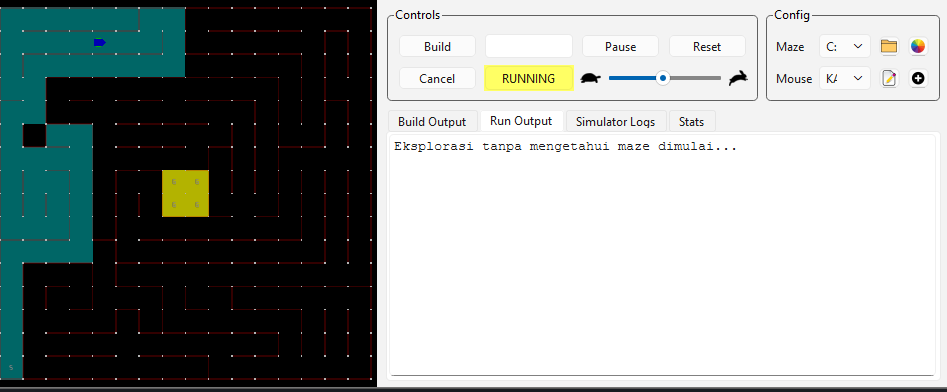
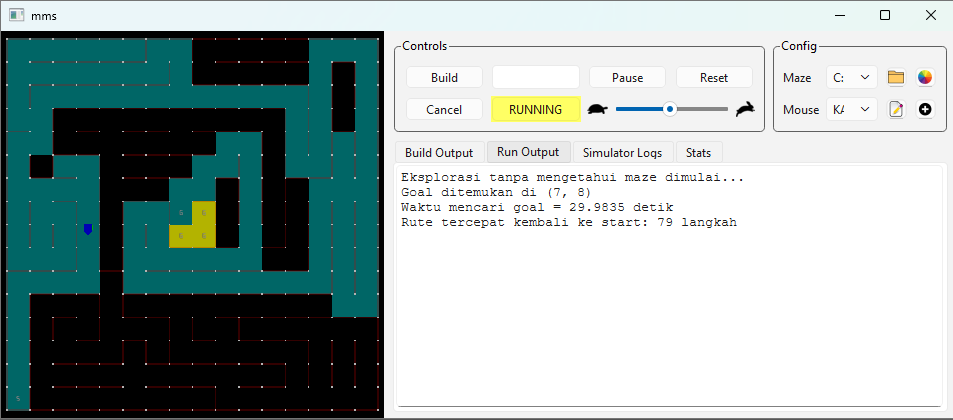
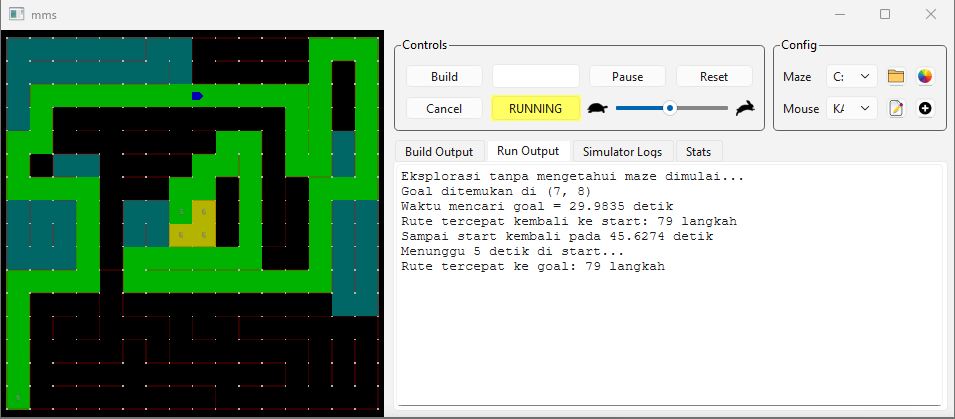

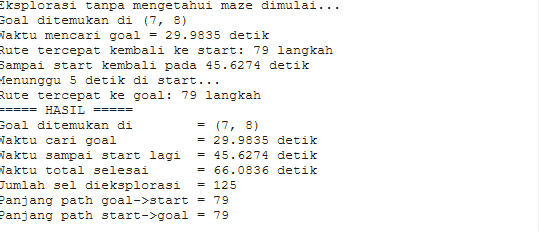

#### Kekurangan
- Kekurangan saat ini terletak pada proses eksplorasi labirin yang belum mampu membaca seluruh area labirin secara menyeluruh. Akibatnya, robot hanya mengenali sebagian jalur yang telah dilalui dan belum memiliki representasi peta lengkap dari lingkungan. Kondisi ini menyebabkan robot belum dapat menentukan jalur terpendek secara optimal menuju titik tujuan, karena perhitungan rute masih didasarkan pada informasi yang terbatas. Dengan kata lain, selama proses eksplorasi, robot belum sepenuhnya mampu membedakan antara jalur yang hanya pernah dilalui dan jalur yang benar-benar paling efisien. Oleh karena itu, diperlukan mekanisme pemetaan yang lebih lengkap agar robot dapat mengidentifikasi seluruh kemungkinan lintasan sebelum menerapkan algoritma pencarian jalur terpendek secara akurat.
#### Perbandinag langsung membaca peta 
- ketika langsung membaca jalur pada alljapan-006-1985-fin.txt 
langkah Penyelesaian Lebih Cepat sekitar 68 langkah

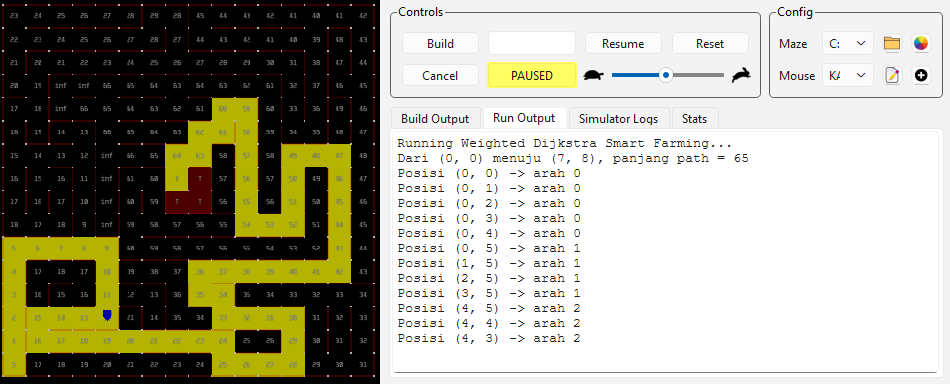
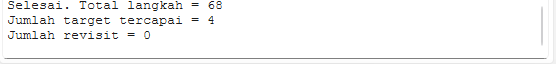